# Классификация пород кошек и собак по лицу

Используем упрощенный датасет [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) с вырезанными лицами домашних животных. Для начала загружаем датасет:

In [1]:
!wget http://www.soshnikov.com/permanent/data/petfaces.tar.gz
!tar xfz petfaces.tar.gz
!rm petfaces.tar.gz

--2026-04-15 11:49:23--  http://www.soshnikov.com/permanent/data/petfaces.tar.gz
Resolving www.soshnikov.com (www.soshnikov.com)... 79.137.227.122
Connecting to www.soshnikov.com (www.soshnikov.com)|79.137.227.122|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24483412 (23M) [application/x-tar]
Saving to: ‘petfaces.tar.gz’

petfaces.tar.gz     100%[===================>]  23.35M   191KB/s    in 2m 7s   

2026-04-15 11:51:31 (188 KB/s) - ‘petfaces.tar.gz’ saved [24483412/24483412]



In [2]:
import os
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import copy
from tqdm.auto import tqdm

Сделаем удобный датафрейм для последующего разделения на лоадеры

In [3]:
# Путь к папке с датасетом
data_dir = 'petfaces'

# Списки для хранения данных
filepaths = []
breeds = []
species =[]

for folder_name in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder_name)

    if os.path.isdir(folder_path):
        parts = folder_name.split('_', 1)

        if len(parts) == 2:
            specie = parts[0]
            breed = parts[1]
        else:
            continue

        for file_name in os.listdir(folder_path):
            if file_name.endswith('.jpg'):
                filepaths.append(os.path.join(folder_path, file_name))
                breeds.append(breed)
                species.append(specie)

df = pd.DataFrame({
    'filepath': filepaths,
    'species': species,
    'breed': breeds
})

print(f"Всего изображений найдено: {len(df)}")
print(f"Количество уникальных пород: {df['breed'].nunique()}")
print("\nРаспределение по видам (собаки/кошки):")
print(df['species'].value_counts())

df.head()

Всего изображений найдено: 3211
Количество уникальных пород: 35

Распределение по видам (собаки/кошки):
species
dog    2105
cat    1106
Name: count, dtype: int64


,filepath,species,breed
0,petfaces/dog_beagle/beagle_168.jpg,dog,beagle
1,petfaces/dog_beagle/beagle_157.jpg,dog,beagle
2,petfaces/dog_beagle/beagle_184.jpg,dog,beagle
3,petfaces/dog_beagle/beagle_126.jpg,dog,beagle
4,petfaces/dog_beagle/beagle_175.jpg,dog,beagle


In [4]:
# Отдаем 80% данных на обучение, 20% на тест.
# Параметр stratify=df['breed'] математически гарантирует,
# что распределение всех пород в train и test будет одинаковым.
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['breed']
)

print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")

class PetDataset(Dataset):
    def __init__(self, dataframe, task='binary', transform=None):
        """
        dataframe: таблица (train_df или test_df)
        task: 'binary' (кошки vs собаки) или 'multiclass' (породы)
        transform: преобразования изображений (аугментация, перевод в тензор)
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.task = task
        self.transform = transform

        if self.task == 'binary':
            self.label_map = {'cat': 0, 'dog': 1}
        else:
            unique_breeds = sorted(self.dataframe['breed'].unique())
            self.label_map = {breed: idx for idx, breed in enumerate(unique_breeds)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row['filepath']

        # Открываем картинку (переводим в RGB, так как бывают черно-белые с 1 каналом)
        image = Image.open(img_path).convert('RGB')

        # Определяем метку класса (таргет)
        if self.task == 'binary':
            label_name = row['species']
        else:
            label_name = row['breed']

        label = self.label_map[label_name]

        # Применяем трансформации
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

print("Разбиение выполнено, класс PetDataset создан успешно!")

Размер обучающей выборки: 2568
Размер тестовой выборки: 643
Разбиение выполнено, класс PetDataset создан успешно!


Для визуализации списка изображений можно использовать такую функцию:

Проверка размеров исходных изображений:
Файл: British_Shorthair_180.jpg | Размер: 157x182
Файл: samoyed_11.jpg | Размер: 170x182
Файл: english_cocker_spaniel_185.jpg | Размер: 69x73
Файл: newfoundland_107.jpg | Размер: 170x183
Файл: Birman_188.jpg | Размер: 151x135


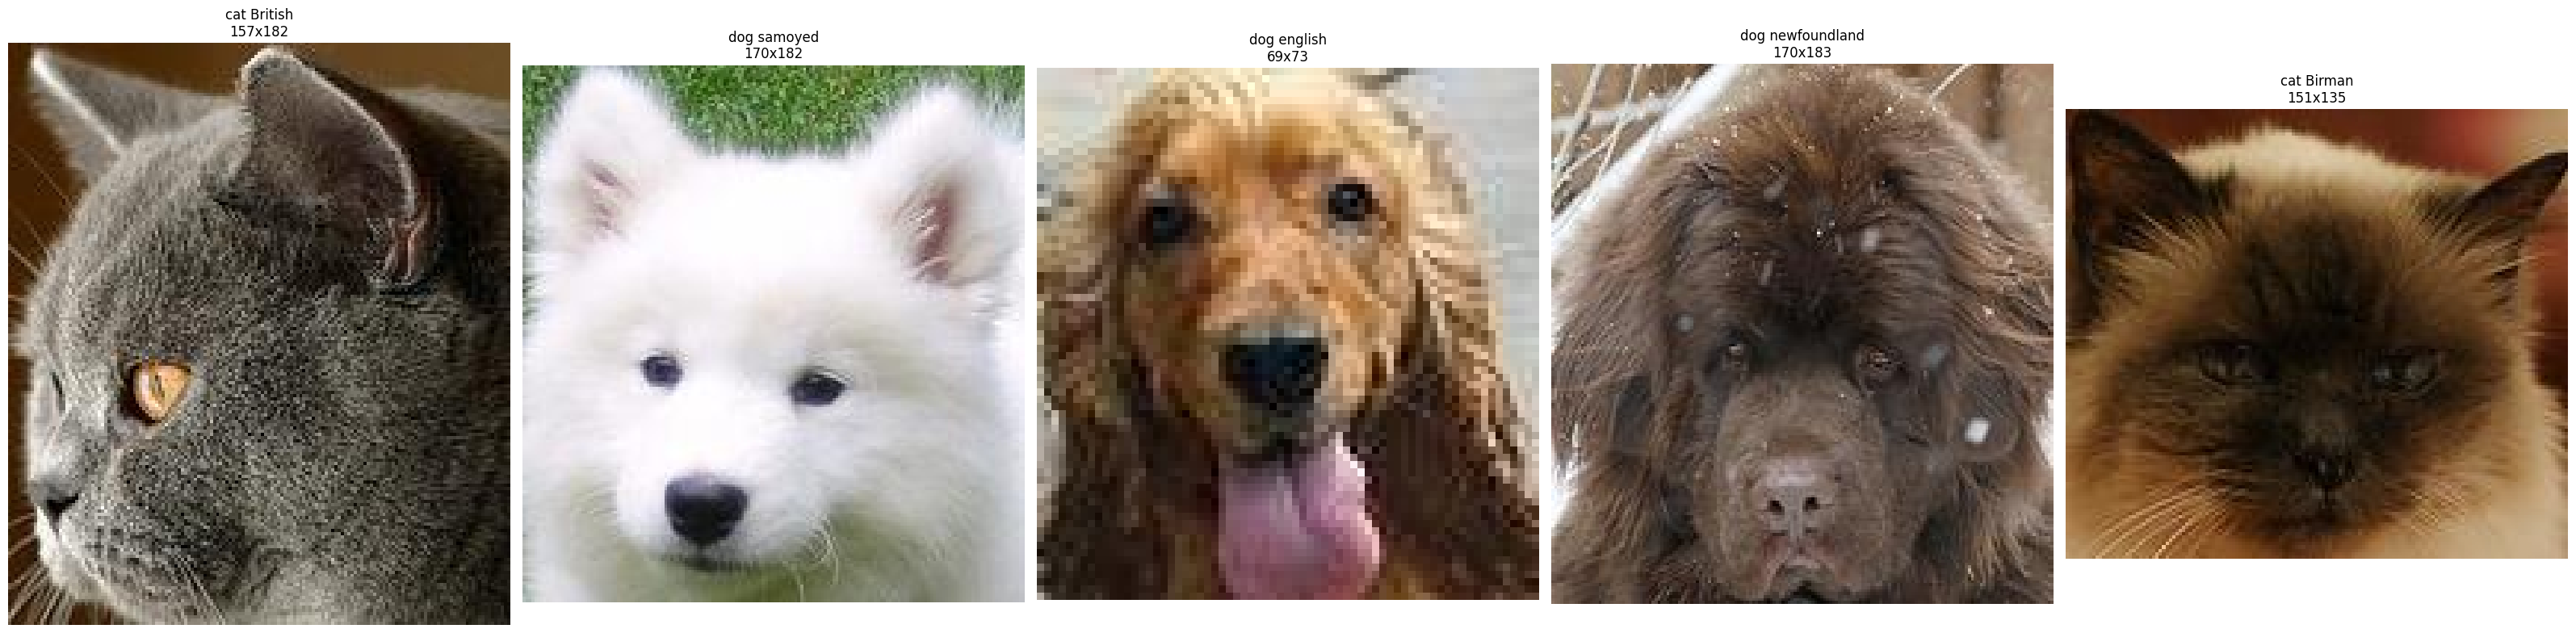


Первые 10 размеров изображений в датасете: [(107, 95), (186, 159), (89, 77), (96, 122), (262, 234), (253, 185), (100, 92), (280, 288), (119, 105), (92, 88)]

Количество всех уникальных размеров изображений в датасете: 2963


In [5]:
def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

# Выберем 5 случайных изображений
random.seed(42)
sample_paths = random.sample(df['filepath'].tolist(), 5)

sample_images = []
sample_titles =[]

print("Проверка размеров исходных изображений:")
for p in sample_paths:
    img = Image.open(p)
    sample_images.append(img)

    w, h = img.size

    # Достаем метку (собака/кошка и порода) для заголовка
    species = p.split('/')[1].split('_')[0]
    breed = p.split('/')[1].split('_')[1]

    title = f"{species} {breed}\n{w}x{h}"
    sample_titles.append(title)

    print(f"Файл: {p.split('/')[-1]} | Размер: {w}x{h}")


display_images(sample_images, titles=sample_titles)

all_sizes = set([Image.open(p).size for p in df['filepath']])
print(f"\nПервые 10 размеров изображений в датасете: {list(all_sizes)[:10]}")
print(f"\nКоличество всех уникальных размеров изображений в датасете: {len(all_sizes)}")

Видно, что изображения разного размера => нужно будет все ресайзнуть перед обучением.

Напишем функции обучения и валидации для одной эпохи, а также функцию для обучения на n эпохах

In [6]:
def fit_one_epoch(model, train_dataloader, optimizer, loss_func, device):
    running_loss = 0.0
    correct_top1 = 0
    total = 0

    model.train()

    for X_batch, y_batch in tqdm(train_dataloader, desc="Training", leave=False):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outp = model(X_batch)
        loss = loss_func(outp, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        _, preds = torch.max(outp, 1)
        correct_top1 += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_top1 = 100 * correct_top1 / total

    return epoch_loss, epoch_top1

def eval_one_epoch(model, val_dataloader, loss_func, device, mode='multiclass'):
    running_loss = 0.0
    correct_top1 = 0
    correct_top3 = 0
    total = 0

    model.eval()

    for X_batch, y_batch in tqdm(val_dataloader, desc="Validation", leave=False):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        with torch.no_grad():
            outp = model(X_batch)
            loss = loss_func(outp, y_batch)

            _, preds = torch.max(outp, 1)
            correct_top1 += (preds == y_batch).sum().item()

            if mode == 'multiclass':
              _, top3_preds = outp.topk(3, dim=1)
              correct_top3 += (top3_preds == y_batch.view(-1, 1)).sum().item()

            running_loss += loss.item() * X_batch.size(0)
            total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_top1 = 100 * correct_top1 / total
    if mode == 'multiclass':
      epoch_top3 = 100 * correct_top3 / total

    if mode == 'multiclass':
      return epoch_loss, epoch_top1, epoch_top3
    else:
      return epoch_loss, epoch_top1

def train_func(model, num_epochs, dataloaders, optimizer, loss_func, device, scheduler=None, mode='multiclass'):

    if mode == 'multiclass':
      history = {'train_loss':[], 'val_loss': [], 'train_top1': [], 'val_top1':[], 'val_top3':[]}
    else:
      history = {'train_loss':[], 'val_loss': [], 'train_top1': [], 'val_top1':[]}

    best_model_weights = copy.deepcopy(model.state_dict())
    best_top1 = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        train_loss, train_top1 = fit_one_epoch(model, dataloaders['train'], optimizer, loss_func, device)

        if mode == 'multiclass':
          val_loss, val_top1, val_top3 = eval_one_epoch(model, dataloaders['val'], loss_func, device, mode)
        else:
          val_loss, val_top1 = eval_one_epoch(model, dataloaders['val'], loss_func, device, mode)

        if scheduler:
            scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_top1'].append(train_top1)
        history['val_top1'].append(val_top1)

        if mode == 'multiclass':
          history['val_top3'].append(val_top3)

        print(f"Train Loss: {train_loss:.4f} | Train Top-1: {train_top1:.2f}%")

        if mode == 'multiclass':
          print(f"Val Loss:   {val_loss:.4f} | Val Top-1:   {val_top1:.2f}% | Val Top-3: {val_top3:.2f}%")
        else:
          print(f"Val Loss:   {val_loss:.4f} | Val Top-1:   {val_top1:.2f}%")

        if val_top1 > best_top1:
            best_top1 = val_top1
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"--> Saved new best model with Val Top-1: {best_top1:.2f}%\n")
        else:
            print()

    print(f"Training complete. Loading best model weights (Top-1: {best_top1:.2f}%)")
    model.load_state_dict(best_model_weights)
    return model, history

In [7]:
# в коллабе есть графика, перейдем на нее
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Обучение будет происходить на: {device}")

Обучение будет происходить на: cuda


# Из-за использования tqdm в процессе обучения гитхаб не даст открыть ноутбук просто так, поэтому все выводы обучения я очищу и прикреплю в виде обычного текста сразу после ячейки

# Оригинальный ноут можно посмотреть по ссылке https://colab.research.google.com/drive/16h5UbqXJRx_SpVG7gM8C2Vb8RKUiPV1b?usp=sharing

# Бинарная моделька

In [8]:
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((128, 128)), # ресайзим все к одному размеру
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset_bin = PetDataset(train_df, task='binary', transform=transform)
test_dataset_bin = PetDataset(test_df, task='binary', transform=transform)

train_loader_bin = DataLoader(train_dataset_bin, batch_size=BATCH_SIZE, shuffle=True)
test_loader_bin = DataLoader(test_dataset_bin, batch_size=BATCH_SIZE, shuffle=False)

# Посмотрим на размерность одного батча
images, labels = next(iter(train_loader_bin))
print(f"Размерность батча картинок: {images.shape}")
print(f"Размерность батча меток: {labels.shape}")
print(f"Пример меток (0 - кошка, 1 - собака): {labels[:10]}")

Размерность батча картинок: torch.Size([32, 3, 128, 128])
Размерность батча меток: torch.Size([32])
Пример меток (0 - кошка, 1 - собака): tensor([0, 1, 1, 1, 0, 1, 1, 1, 0, 1])


Начнем с простой модельки с тремя сверточными слоями и двумя полносвязными

In [13]:
class BinaryPetNet(nn.Module):
    def __init__(self):
        super(BinaryPetNet, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Уменьшает картинку в 2 раза

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # После трех слоев MaxPool картинка 128x128 уменьшится до 16x16.
        # У нас 64 фильтра, поэтому признаков будет: 64 * 16 * 16 = 16384
        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):

        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 16 * 16)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_bin = BinaryPetNet().to(device)
print(model_bin)

BinaryPetNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)


Обучим и посмотрим на результат

In [14]:
dataloaders = {
    'train': train_loader_bin,
    'val': test_loader_bin
}

In [ ]:
optimizer_bin = optim.Adam(model_bin.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model_bin, history_bin = train_func(model_bin, 10, dataloaders, optimizer_bin, criterion, device, mode='bin')

 Epoch 1/10
Train Loss: 0.4508 | Train Top-1: 77.84%
Val Loss:   0.3263 | Val Top-1:   84.60%
--> Saved new best model with Val Top-1: 84.60%

Epoch 2/10
Train Loss: 0.2589 | Train Top-1: 89.37%
Val Loss:   0.2573 | Val Top-1:   88.80%
--> Saved new best model with Val Top-1: 88.80%

Epoch 3/10
Train Loss: 0.1596 | Train Top-1: 94.24%
Val Loss:   0.2868 | Val Top-1:   88.65%

Epoch 4/10
Train Loss: 0.1012 | Train Top-1: 96.22%
Val Loss:   0.2411 | Val Top-1:   90.98%
--> Saved new best model with Val Top-1: 90.98%

Epoch 5/10
Train Loss: 0.0852 | Train Top-1: 96.69%
Val Loss:   0.2525 | Val Top-1:   90.36%

Epoch 6/10
Train Loss: 0.0335 | Train Top-1: 98.75%
Val Loss:   0.2887 | Val Top-1:   92.22%
--> Saved new best model with Val Top-1: 92.22%

Epoch 7/10
Train Loss: 0.0484 | Train Top-1: 98.36%
Val Loss:   0.3055 | Val Top-1:   91.45%

Epoch 8/10
Train Loss: 0.0108 | Train Top-1: 99.73%
Val Loss:   0.3873 | Val Top-1:   90.67%

Epoch 9/10
Train Loss: 0.0086 | Train Top-1: 99.81%
Val Loss:   0.4306 | Val Top-1:   91.91%

Epoch 10/10
Train Loss: 0.0034 | Train Top-1: 99.96%
Val Loss:   0.4617 | Val Top-1:   91.60%

Training complete. Loading best model weights (Top-1: 92.22%)


Построим confusion matrix

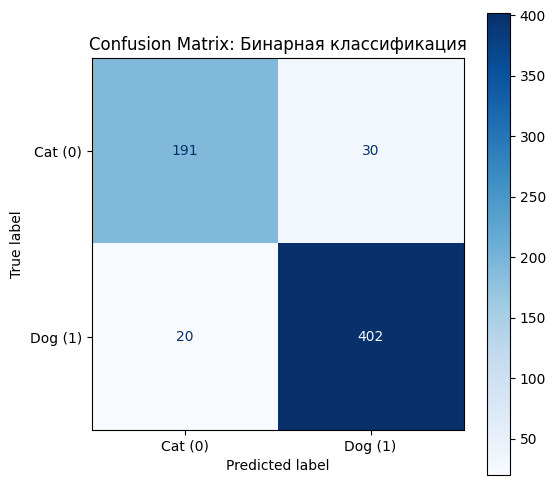

In [16]:
model_bin.eval()
all_preds =[]
all_true =[]

with torch.no_grad():
    for images, labels in test_loader_bin:
        images, labels = images.to(device), labels.to(device)
        outputs = model_bin(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

cm = confusion_matrix(all_true, all_preds)

class_names = ['Cat (0)', 'Dog (1)']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix: Бинарная классификация")
plt.show()

Видно, что моделька реально определяет 92.22% правильно, причем количество неправильно определенных собак и кошек недалеко друг от друга, что говорит о хорошем разбиении на train/test без перекоса по классам.

# Мультиклассовая моделька

In [17]:
train_dataset_multi = PetDataset(train_df, task='multiclass', transform=transform)
test_dataset_multi = PetDataset(test_df, task='multiclass', transform=transform)

train_loader_multi = DataLoader(train_dataset_multi, batch_size=BATCH_SIZE, shuffle=True)
test_loader_multi = DataLoader(test_dataset_multi, batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(train_dataset_multi.label_map)
print(f"Количество классов (пород) для обучения: {NUM_CLASSES}")

class MultiClassPetNet(nn.Module):
    def __init__(self, num_classes):
        super(MultiClassPetNet, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 16 * 16)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_multi = MultiClassPetNet(NUM_CLASSES).to(device)
print(model_multi)

Количество классов (пород) для обучения: 35
MultiClassPetNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=35, bias=True)
)


Обучим

In [18]:
dataloaders = {
    'train': train_loader_multi,
    'val': test_loader_multi
}

In [ ]:
optimizer_multi = optim.Adam(model_multi.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model_multi, history_bin = train_func(model_multi, 10, dataloaders, optimizer_multi, criterion, device)

 Epoch 1/10
Train Loss: 3.0623 | Train Top-1: 15.58%
Val Loss:   2.6429 | Val Top-1:   24.73% | Val Top-3: 49.46%
--> Saved new best model with Val Top-1: 24.73%

Epoch 2/10
Train Loss: 1.9865 | Train Top-1: 41.98%
Val Loss:   2.0894 | Val Top-1:   39.19% | Val Top-3: 63.92%
--> Saved new best model with Val Top-1: 39.19%

Epoch 3/10
Train Loss: 1.2504 | Train Top-1: 61.92%
Val Loss:   1.9601 | Val Top-1:   44.01% | Val Top-3: 69.21%
--> Saved new best model with Val Top-1: 44.01%

Epoch 4/10
Train Loss: 0.6291 | Train Top-1: 80.65%
Val Loss:   2.1508 | Val Top-1:   45.72% | Val Top-3: 70.92%
--> Saved new best model with Val Top-1: 45.72%

Epoch 5/10
Train Loss: 0.2959 | Train Top-1: 90.69%
Val Loss:   2.3087 | Val Top-1:   44.63% | Val Top-3: 74.96%

Epoch 6/10
Train Loss: 0.1739 | Train Top-1: 94.55%
Val Loss:   2.6704 | Val Top-1:   46.97% | Val Top-3: 72.78%
--> Saved new best model with Val Top-1: 46.97%

Epoch 7/10
Train Loss: 0.0439 | Train Top-1: 98.83%
Val Loss:   3.0332 | Val Top-1:   51.32% | Val Top-3: 73.41%
--> Saved new best model with Val Top-1: 51.32%

Epoch 8/10
Train Loss: 0.0435 | Train Top-1: 98.83%
Val Loss:   3.2745 | Val Top-1:   48.21% | Val Top-3: 71.38%

Epoch 9/10
Train Loss: 0.0493 | Train Top-1: 98.60%
Val Loss:   3.5826 | Val Top-1:   48.99% | Val Top-3: 70.30%

Epoch 10/10
Train Loss: 0.0327 | Train Top-1: 99.07%
Val Loss:   3.2306 | Val Top-1:   46.50% | Val Top-3: 73.41%

Training complete. Loading best model weights (Top-1: 51.32%)


Видим в конце обучения топ3 accuracy == 73.41% - неплохо для простой сетки с 35 выходными классами

# Оптимизация

Мы увидели, что в обоих случаях (и бинарке, и многоклассовой) за 10 эпох результат на трейне или стал 100%, или почти до него добрался. Очевидно, что обе модели переобучились на трейн дате. Давайте проведем некую оптимизацию и глянем на аутпут после ее применения

**Первый** эксперимент - увеличим количество сверточных слоев

In [20]:
class more_layers(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(2, 2)

        # После 4 пулингов: 128 -> 64 -> 32 -> 16 -> 8. Итого 8x8
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))
        x = x.view(-1, 128 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model_exp1 = more_layers(NUM_CLASSES).to(device)
print(model_exp1)

more_layers(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=35, bias=True)
)


In [ ]:
print("Эксперимент с бОльшим количестом слоев")

optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model_exp1, history_exp1 = train_func(model_exp1, 10, dataloaders, optimizer_exp1, criterion, device)

 Эксперимент с бОльшим количестом слоев
Epoch 1/10
Train Loss: 3.2342 | Train Top-1: 10.48%
Val Loss:   2.7924 | Val Top-1:   18.04% | Val Top-3: 42.30%
--> Saved new best model with Val Top-1: 18.04%

Epoch 2/10
Train Loss: 2.3319 | Train Top-1: 32.52%
Val Loss:   2.1362 | Val Top-1:   38.41% | Val Top-3: 64.39%
--> Saved new best model with Val Top-1: 38.41%

Epoch 3/10
Train Loss: 1.5743 | Train Top-1: 53.15%
Val Loss:   1.9521 | Val Top-1:   46.19% | Val Top-3: 72.47%
--> Saved new best model with Val Top-1: 46.19%

Epoch 4/10
Train Loss: 1.0130 | Train Top-1: 67.91%
Val Loss:   1.8567 | Val Top-1:   47.74% | Val Top-3: 72.63%
--> Saved new best model with Val Top-1: 47.74%

Epoch 5/10
Train Loss: 0.5400 | Train Top-1: 83.10%
Val Loss:   2.3699 | Val Top-1:   49.92% | Val Top-3: 72.32%
--> Saved new best model with Val Top-1: 49.92%

Epoch 6/10
Train Loss: 0.2771 | Train Top-1: 91.28%
Val Loss:   2.4094 | Val Top-1:   51.01% | Val Top-3: 75.43%
--> Saved new best model with Val Top-1: 51.01%

Epoch 7/10
Train Loss: 0.1293 | Train Top-1: 96.18%
Val Loss:   3.4658 | Val Top-1:   50.39% | Val Top-3: 73.87%

Epoch 8/10
Train Loss: 0.1112 | Train Top-1: 96.46%
Val Loss:   3.0965 | Val Top-1:   51.01% | Val Top-3: 73.87%

Epoch 9/10
Train Loss: 0.0912 | Train Top-1: 96.96%
Val Loss:   3.9944 | Val Top-1:   46.03% | Val Top-3: 69.67%

Epoch 10/10
Train Loss: 0.0976 | Train Top-1: 97.08%
Val Loss:   3.8500 | Val Top-1:   47.90% | Val Top-3: 72.01%

Training complete. Loading best model weights (Top-1: 51.01%)

Хоть точность на топ3 accuracy и повысилась до 75.43%, все равно ловим жесткое переобучение --> увеличение количества слоев не помогло (в принципе, ожидаемо)

А что если **уменьшить** количество слоев? Проверим

In [22]:
class less_layers(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        # После 2 пулингов: 128 -> 64 -> 32. Итого 32x32
        self.fc1 = nn.Linear(64 * 32 * 32, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model_exp1 = less_layers(NUM_CLASSES).to(device)
print(model_exp1)

less_layers(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=65536, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=35, bias=True)
)


In [ ]:
print("Эксперимент с меньшим количестом слоев")

optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model_exp1, history_exp1 = train_func(model_exp1, 10, dataloaders, optimizer_exp1, criterion, device)

 Эксперимент с меньшим количестом слоев
Epoch 1/10
Train Loss: 3.3625 | Train Top-1: 10.36%
Val Loss:   2.7752 | Val Top-1:   23.02% | Val Top-3: 46.97%
--> Saved new best model with Val Top-1: 23.02%

Epoch 2/10
Train Loss: 2.3343 | Train Top-1: 32.79%
Val Loss:   2.3173 | Val Top-1:   33.28% | Val Top-3: 59.72%
--> Saved new best model with Val Top-1: 33.28%

Epoch 3/10
Train Loss: 1.4373 | Train Top-1: 57.44%
Val Loss:   2.0673 | Val Top-1:   42.61% | Val Top-3: 66.87%
--> Saved new best model with Val Top-1: 42.61%

Epoch 4/10
Train Loss: 0.6869 | Train Top-1: 79.98%
Val Loss:   2.2441 | Val Top-1:   43.39% | Val Top-3: 65.47%
--> Saved new best model with Val Top-1: 43.39%

Epoch 5/10
Train Loss: 0.2369 | Train Top-1: 93.07%
Val Loss:   2.6135 | Val Top-1:   44.32% | Val Top-3: 65.32%
--> Saved new best model with Val Top-1: 44.32%

Epoch 6/10
Train Loss: 0.0554 | Train Top-1: 98.87%
Val Loss:   2.7522 | Val Top-1:   48.06% | Val Top-3: 68.90%
--> Saved new best model with Val Top-1: 48.06%

Epoch 7/10
Train Loss: 0.0149 | Train Top-1: 99.84%
Val Loss:   2.9507 | Val Top-1:   48.52% | Val Top-3: 71.07%
--> Saved new best model with Val Top-1: 48.52%

Epoch 8/10
Train Loss: 0.0026 | Train Top-1: 100.00%
Val Loss:   3.0459 | Val Top-1:   48.83% | Val Top-3: 70.92%
--> Saved new best model with Val Top-1: 48.83%

Epoch 9/10
Train Loss: 0.0012 | Train Top-1: 100.00%
Val Loss:   3.1555 | Val Top-1:   49.46% | Val Top-3: 70.61%
--> Saved new best model with Val Top-1: 49.46%

Epoch 10/10
Train Loss: 0.0008 | Train Top-1: 100.00%
Val Loss:   3.2192 | Val Top-1:   49.92% | Val Top-3: 71.23%
--> Saved new best model with Val Top-1: 49.92%

Training complete. Loading best model weights (Top-1: 49.92%)


Переобучение присутсвует страшнейшее))) Причем на валидационной точность упала, что следует о нехватке слоев. Получается, слои не особо помогают бороться с переобучением как при их увеличении, так и при уменьшении. А что делать то? Попробуем что-то другое

**Второй** эксперимент - поменяем размеры ядер

In [28]:
class Diff_kernel_size(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Используем 5x5 на первых двух слоях для захвата крупных признаков
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(2, 2)
        # На глубоких слоях оставляем 3x3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(2, 2)


        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))
        x = x.view(-1, 128 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_exp2 = Diff_kernel_size(NUM_CLASSES).to(device)
print(model_exp2)

Diff_kernel_size(
  (conv1): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=35, bias=True)
)


In [ ]:
print("Эксперимент с бОльшими количестом фильтров")
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=0.001)

model_exp2, history_exp2 = train_func(model_exp2, 10, dataloaders, optimizer_exp2, criterion, device)

 Эксперимент с бОльшими количестом фильтров
Epoch 1/10
Train Loss: 3.2842 | Train Top-1: 9.97%
Val Loss:   3.0337 | Val Top-1:   14.93% | Val Top-3: 33.13%
--> Saved new best model with Val Top-1: 14.93%

Epoch 2/10
Train Loss: 2.5662 | Train Top-1: 27.38%
Val Loss:   2.4279 | Val Top-1:   31.57% | Val Top-3: 55.52%
--> Saved new best model with Val Top-1: 31.57%

Epoch 3/10
Train Loss: 1.8372 | Train Top-1: 46.57%
Val Loss:   2.0235 | Val Top-1:   42.92% | Val Top-3: 67.81%
--> Saved new best model with Val Top-1: 42.92%

Epoch 4/10
Train Loss: 1.2323 | Train Top-1: 63.12%
Val Loss:   1.9379 | Val Top-1:   46.97% | Val Top-3: 70.30%
--> Saved new best model with Val Top-1: 46.97%

Epoch 5/10
Train Loss: 0.6888 | Train Top-1: 78.23%
Val Loss:   2.2674 | Val Top-1:   43.70% | Val Top-3: 69.98%

Epoch 6/10
Train Loss: 0.3537 | Train Top-1: 88.55%
Val Loss:   2.9117 | Val Top-1:   47.12% | Val Top-3: 70.45%
--> Saved new best model with Val Top-1: 47.12%

Epoch 7/10
Train Loss: 0.1787 | Train Top-1: 94.00%
Val Loss:   2.8909 | Val Top-1:   48.21% | Val Top-3: 71.23%
--> Saved new best model with Val Top-1: 48.21%

Epoch 8/10
Train Loss: 0.1050 | Train Top-1: 96.57%
Val Loss:   3.8483 | Val Top-1:   45.88% | Val Top-3: 68.90%

Epoch 9/10
Train Loss: 0.1097 | Train Top-1: 96.85%
Val Loss:   3.7082 | Val Top-1:   46.19% | Val Top-3: 72.32%

Epoch 10/10
Train Loss: 0.0934 | Train Top-1: 97.12%
Val Loss:   3.8957 | Val Top-1:   47.59% | Val Top-3: 70.14%

Training complete. Loading best model weights (Top-1: 48.21%)


Все еще присутствует переобучение, причем точность по топ1 упала. Перезапускал обучение несколько раз, из них пару вывело чуть большую точность по топ1, последний раз вот меньше. Вывод такой - с переобучением не поборолись

Ластовый эксперимент - докидываем изменение learning rate, batch_norm, dropout и предыдущие шаги вместе.

In [30]:
class Ultimate_net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool4 = nn.MaxPool2d(2, 2)

        # Размер после 4 пулингов: 128 -> 64 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(128 * 8 * 8, 1024)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))

        x = x.view(-1, 128 * 8 * 8)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model_final = Ultimate_net(NUM_CLASSES).to(device)
print(model_final)

Ultimate_net(
  (conv1): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dil

In [ ]:
optimizer_final = optim.Adam(model_final.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer_final, step_size=5, gamma=0.5)
criterion = nn.CrossEntropyLoss()

print("Финалочный")
model_final, history_final = train_func(
    model_final, 15, dataloaders, optimizer_final, criterion, device, scheduler=scheduler
)

 Финалочный
Epoch 1/15
Train Loss: 4.1638 | Train Top-1: 6.11%
Val Loss:   3.1434 | Val Top-1:   14.00% | Val Top-3: 32.19%
--> Saved new best model with Val Top-1: 14.00%

Epoch 2/15
Train Loss: 3.1416 | Train Top-1: 13.08%
Val Loss:   3.0731 | Val Top-1:   15.55% | Val Top-3: 34.68%
--> Saved new best model with Val Top-1: 15.55%

Epoch 3/15
Train Loss: 2.8788 | Train Top-1: 17.29%
Val Loss:   2.7366 | Val Top-1:   26.13% | Val Top-3: 47.90%
--> Saved new best model with Val Top-1: 26.13%

Epoch 4/15
Train Loss: 2.6746 | Train Top-1: 22.20%
Val Loss:   2.5667 | Val Top-1:   29.08% | Val Top-3: 54.59%
--> Saved new best model with Val Top-1: 29.08%

Epoch 5/15
Train Loss: 2.4486 | Train Top-1: 28.39%
Val Loss:   2.3795 | Val Top-1:   31.57% | Val Top-3: 57.85%
--> Saved new best model with Val Top-1: 31.57%

Epoch 6/15
Train Loss: 2.1437 | Train Top-1: 34.23%
Val Loss:   2.0782 | Val Top-1:   38.57% | Val Top-3: 66.72%
--> Saved new best model with Val Top-1: 38.57%

Epoch 7/15
Train Loss: 1.9976 | Train Top-1: 38.51%
Val Loss:   2.0617 | Val Top-1:   41.52% | Val Top-3: 66.41%
--> Saved new best model with Val Top-1: 41.52%

Epoch 8/15
Train Loss: 1.8399 | Train Top-1: 43.54%
Val Loss:   1.8607 | Val Top-1:   45.57% | Val Top-3: 72.63%
--> Saved new best model with Val Top-1: 45.57%

Epoch 9/15
Train Loss: 1.7417 | Train Top-1: 47.08%
Val Loss:   1.7769 | Val Top-1:   48.37% | Val Top-3: 73.87%
--> Saved new best model with Val Top-1: 48.37%

Epoch 10/15
Train Loss: 1.6175 | Train Top-1: 49.30%
Val Loss:   1.7480 | Val Top-1:   49.92% | Val Top-3: 74.03%
--> Saved new best model with Val Top-1: 49.92%

Epoch 11/15
Train Loss: 1.4505 | Train Top-1: 54.17%
Val Loss:   1.5956 | Val Top-1:   52.57% | Val Top-3: 75.74%
--> Saved new best model with Val Top-1: 52.57%

Epoch 12/15
Train Loss: 1.3296 | Train Top-1: 56.58%
Val Loss:   1.5325 | Val Top-1:   54.43% | Val Top-3: 78.38%
--> Saved new best model with Val Top-1: 54.43%

Epoch 13/15
Train Loss: 1.2534 | Train Top-1: 59.81%
Val Loss:   1.5268 | Val Top-1:   52.88% | Val Top-3: 78.54%

Epoch 14/15
Train Loss: 1.2066 | Train Top-1: 62.66%
Val Loss:   1.5686 | Val Top-1:   54.43% | Val Top-3: 77.45%

Epoch 15/15
Train Loss: 1.1082 | Train Top-1: 64.68%
Val Loss:   1.4954 | Val Top-1:   55.68% | Val Top-3: 79.32%
--> Saved new best model with Val Top-1: 55.68%

Training complete. Loading best model weights (Top-1: 55.68%)


ОГО!!! Переобучение то пропало, кажется. Теперь видим около одинаковые значения на трейне и вале по топ1, а вал по топ3 вообще вырос по сравнению с бейзлайном. Вывод такой - батчнорм с дропаутом дико помогли побороть переобучение

Построим матрицу для всех пород

Результаты
Точность классификации пород (Top-1): 55.68%
Точность классификации пород (Top-3): 79.32%
Точность 'Кошки против Собак' (Binary): 90.67%


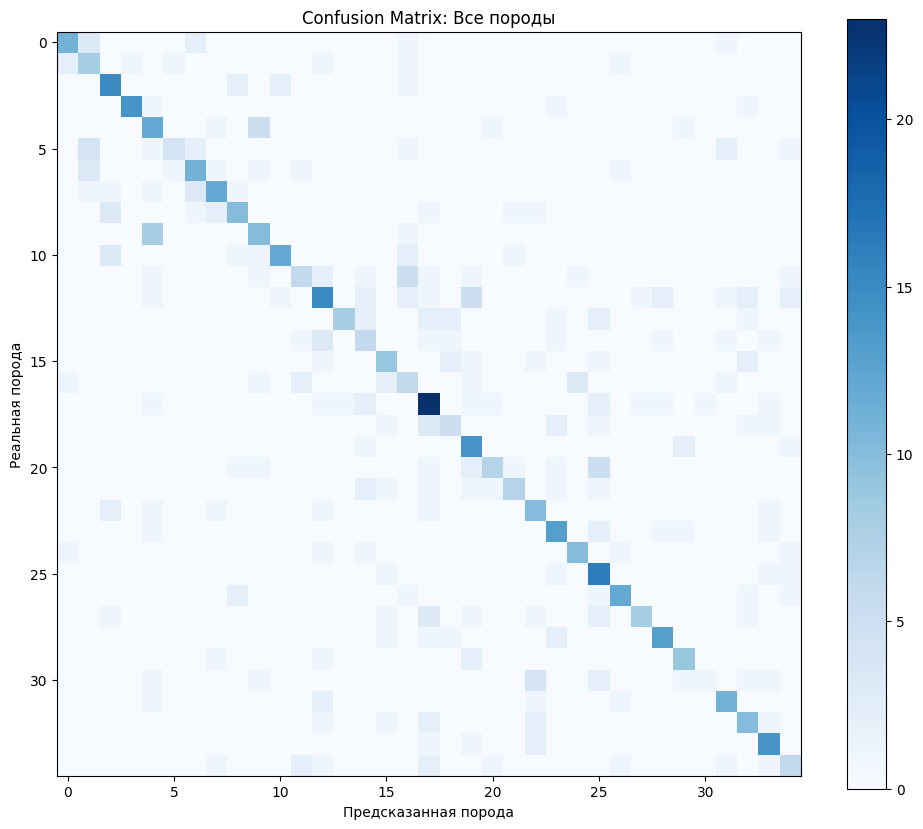

In [32]:
model_final.eval()
all_preds = []
all_true_breeds = []
all_true_species = []

idx_to_breed = {v: k for k, v in test_dataset_multi.label_map.items()}
breed_to_species = df.set_index('breed')['species'].to_dict()

with torch.no_grad():
    for images, labels in test_loader_multi:
        images = images.to(device)
        outputs = model_final(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_true_breeds.extend(labels.numpy())

# Переводим предсказания пород в виды (0 для кошек, 1 для собак)
binary_preds = [0 if breed_to_species[idx_to_breed[p]] == 'cat' else 1 for p in all_preds]
binary_true = [0 if breed_to_species[idx_to_breed[t]] == 'cat' else 1 for t in all_true_breeds]

# Считаем метрики
final_acc = accuracy_score(all_true_breeds, all_preds)
final_binary_acc = accuracy_score(binary_true, binary_preds)
final_top3 = history_final['val_top3'][-1]

print("Результаты")
print(f"Точность классификации пород (Top-1): {final_acc*100:.2f}%")
print(f"Точность классификации пород (Top-3): {final_top3:.2f}%")
print(f"Точность 'Кошки против Собак' (Binary): {final_binary_acc*100:.2f}%")

# Построение Confusion Matrix (для пород)
cm = confusion_matrix(all_true_breeds, all_preds)
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Все породы")
plt.colorbar()
plt.xlabel("Предсказанная порода")
plt.ylabel("Реальная порода")
plt.show()

Готово, вроде)